In [1]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("✅ Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

✅ Libraries imported successfully!
Pandas version: 2.2.2
Numpy version: 1.26.4


In [2]:
# Cell 2: Load Dataset
df = pd.read_csv('../../data/raw/creditcard.csv')

print("✅ Dataset loaded successfully!")
print(f"\nDataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn Names:\n{df.columns.tolist()}")

✅ Dataset loaded successfully!

Dataset Shape: (284807, 31)
Rows: 284,807
Columns: 31

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [3]:
# Cell 3: Basic Data Inspection
print("=" * 50)
print("FIRST 5 ROWS:")
print("=" * 50)
print(df.head())

print("\n" + "=" * 50)
print("DATA TYPES & NON-NULL COUNTS:")
print("=" * 50)
print(df.info())

print("\n" + "=" * 50)
print("BASIC STATISTICS:")
print("=" * 50)
print(df[['Time', 'Amount', 'Class']].describe())

FIRST 5 ROWS:
    Time      V1      V2     V3      V4      V5      V6      V7      V8  \
0 0.0000 -1.3598 -0.0728 2.5363  1.3782 -0.3383  0.4624  0.2396  0.0987   
1 0.0000  1.1919  0.2662 0.1665  0.4482  0.0600 -0.0824 -0.0788  0.0851   
2 1.0000 -1.3584 -1.3402 1.7732  0.3798 -0.5032  1.8005  0.7915  0.2477   
3 1.0000 -0.9663 -0.1852 1.7930 -0.8633 -0.0103  1.2472  0.2376  0.3774   
4 2.0000 -1.1582  0.8777 1.5487  0.4030 -0.4072  0.0959  0.5929 -0.2705   

       V9     V10     V11     V12     V13     V14     V15     V16     V17  \
0  0.3638  0.0908 -0.5516 -0.6178 -0.9914 -0.3112  1.4682 -0.4704  0.2080   
1 -0.2554 -0.1670  1.6127  1.0652  0.4891 -0.1438  0.6356  0.4639 -0.1148   
2 -1.5147  0.2076  0.6245  0.0661  0.7173 -0.1659  2.3459 -2.8901  1.1100   
3 -1.3870 -0.0550 -0.2265  0.1782  0.5078 -0.2879 -0.6314 -1.0596 -0.6841   
4  0.8177  0.7531 -0.8228  0.5382  1.3459 -1.1197  0.1751 -0.4514 -0.2370   

      V18     V19     V20     V21     V22     V23     V24     V25     V2

CLASS DISTRIBUTION ANALYSIS
Total Transactions:  284,807
Legitimate (0):      284,315 (99.8273%)
Fraud (1):           492 (0.1727%)

Imbalance Ratio:     578:1


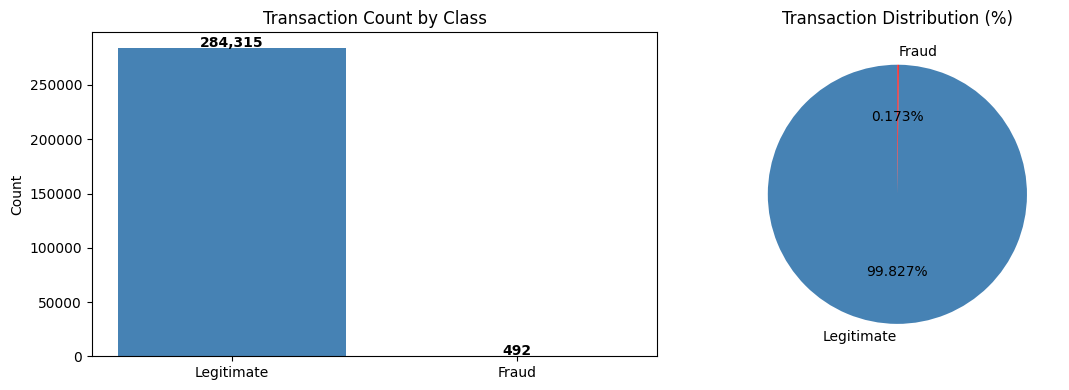


✅ Plot saved to docs/class_distribution.png


In [4]:
# Cell 4: Class Distribution Analysis (The Most Important Check)
fraud = df[df['Class'] == 1]
legitimate = df[df['Class'] == 0]

print("=" * 50)
print("CLASS DISTRIBUTION ANALYSIS")
print("=" * 50)
print(f"Total Transactions:  {len(df):,}")
print(f"Legitimate (0):      {len(legitimate):,} ({len(legitimate)/len(df)*100:.4f}%)")
print(f"Fraud (1):           {len(fraud):,} ({len(fraud)/len(df)*100:.4f}%)")
print(f"\nImbalance Ratio:     {len(legitimate)/len(fraud):.0f}:1")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Count
axes[0].bar(['Legitimate', 'Fraud'], [len(legitimate), len(fraud)], 
            color=['steelblue', 'red'])
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')
for i, v in enumerate([len(legitimate), len(fraud)]):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Plot 2: Percentage
axes[1].pie([len(legitimate), len(fraud)], 
            labels=['Legitimate', 'Fraud'],
            colors=['steelblue', 'red'],
            autopct='%1.3f%%',
            startangle=90)
axes[1].set_title('Transaction Distribution (%)')

plt.tight_layout()
plt.savefig('../../docs/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Plot saved to docs/class_distribution.png")

TRANSACTION AMOUNT ANALYSIS

Legitimate Transactions:
count   284315.0000
mean        88.2910
std        250.1051
min          0.0000
25%          5.6500
50%         22.0000
75%         77.0500
max      25691.1600
Name: Amount, dtype: float64

Fraud Transactions:
count    492.0000
mean     122.2113
std      256.6833
min        0.0000
25%        1.0000
50%        9.2500
75%      105.8900
max     2125.8700
Name: Amount, dtype: float64


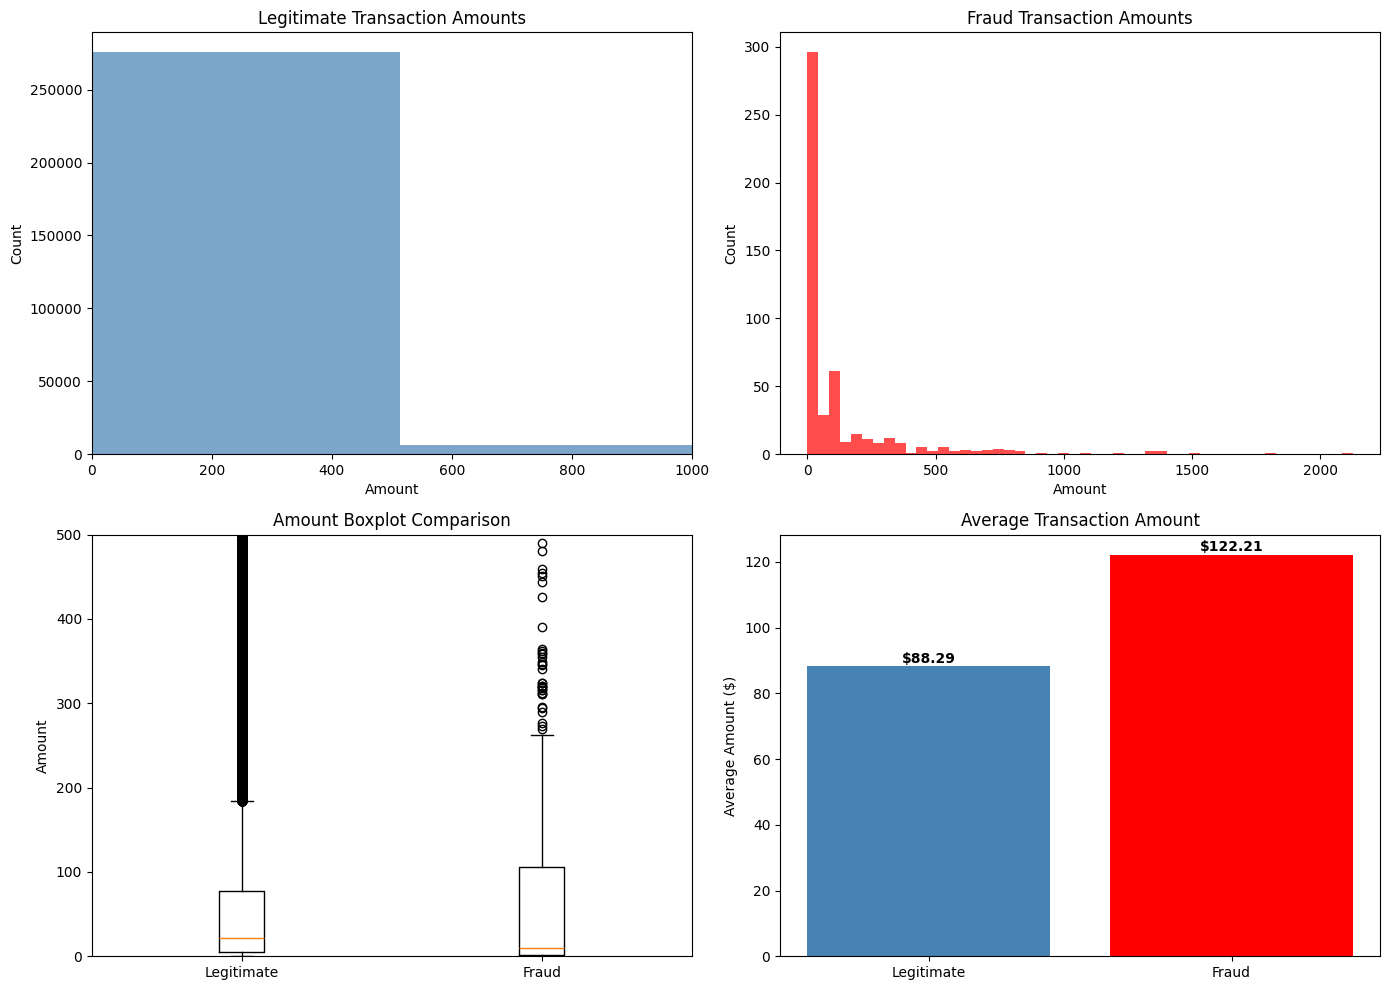

✅ Plot saved to docs/amount_analysis.png


In [5]:
# Cell 5: Fraud vs Legitimate - Amount Analysis
print("=" * 50)
print("TRANSACTION AMOUNT ANALYSIS")
print("=" * 50)
print("\nLegitimate Transactions:")
print(legitimate['Amount'].describe())
print("\nFraud Transactions:")
print(fraud['Amount'].describe())

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Amount distribution - Legitimate
axes[0,0].hist(legitimate['Amount'], bins=50, color='steelblue', alpha=0.7)
axes[0,0].set_title('Legitimate Transaction Amounts')
axes[0,0].set_xlabel('Amount')
axes[0,0].set_ylabel('Count')
axes[0,0].set_xlim(0, 1000)

# Plot 2: Amount distribution - Fraud
axes[0,1].hist(fraud['Amount'], bins=50, color='red', alpha=0.7)
axes[0,1].set_title('Fraud Transaction Amounts')
axes[0,1].set_xlabel('Amount')
axes[0,1].set_ylabel('Count')

# Plot 3: Boxplot comparison
axes[1,0].boxplot([legitimate['Amount'], fraud['Amount']], 
                   labels=['Legitimate', 'Fraud'])
axes[1,0].set_title('Amount Boxplot Comparison')
axes[1,0].set_ylabel('Amount')
axes[1,0].set_ylim(0, 500)

# Plot 4: Average amount
avg_amounts = [legitimate['Amount'].mean(), fraud['Amount'].mean()]
axes[1,1].bar(['Legitimate', 'Fraud'], avg_amounts, 
               color=['steelblue', 'red'])
axes[1,1].set_title('Average Transaction Amount')
axes[1,1].set_ylabel('Average Amount ($)')
for i, v in enumerate(avg_amounts):
    axes[1,1].text(i, v + 1, f'${v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../../docs/amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved to docs/amount_analysis.png")

TIME ANALYSIS
Dataset covers: 48.0 hours (~2 days)

HOURLY BREAKDOWN: Legitimate vs Fraud
Hour      Total    Legit    Fraud     Fraud%
------------------------------------------------------------
0         7,695    7,689        6     0.0780%
1         4,220    4,210       10     0.2370%
2         3,328    3,271       57     1.7127%
3         3,492    3,475       17     0.4868%
4         2,209    2,186       23     1.0412%
5         2,990    2,979       11     0.3679%
6         4,101    4,092        9     0.2195%
7         7,243    7,220       23     0.3175%
8        10,276   10,267        9     0.0876%
9        15,838   15,822       16     0.1010%
10       16,598   16,590        8     0.0482%
11       16,856   16,803       53     0.3144%
12       15,420   15,403       17     0.1102%
13       15,365   15,348       17     0.1106%
14       16,570   16,547       23     0.1388%
15       16,461   16,435       26     0.1579%
16       16,453   16,431       22     0.1337%
17       16,166   16,1

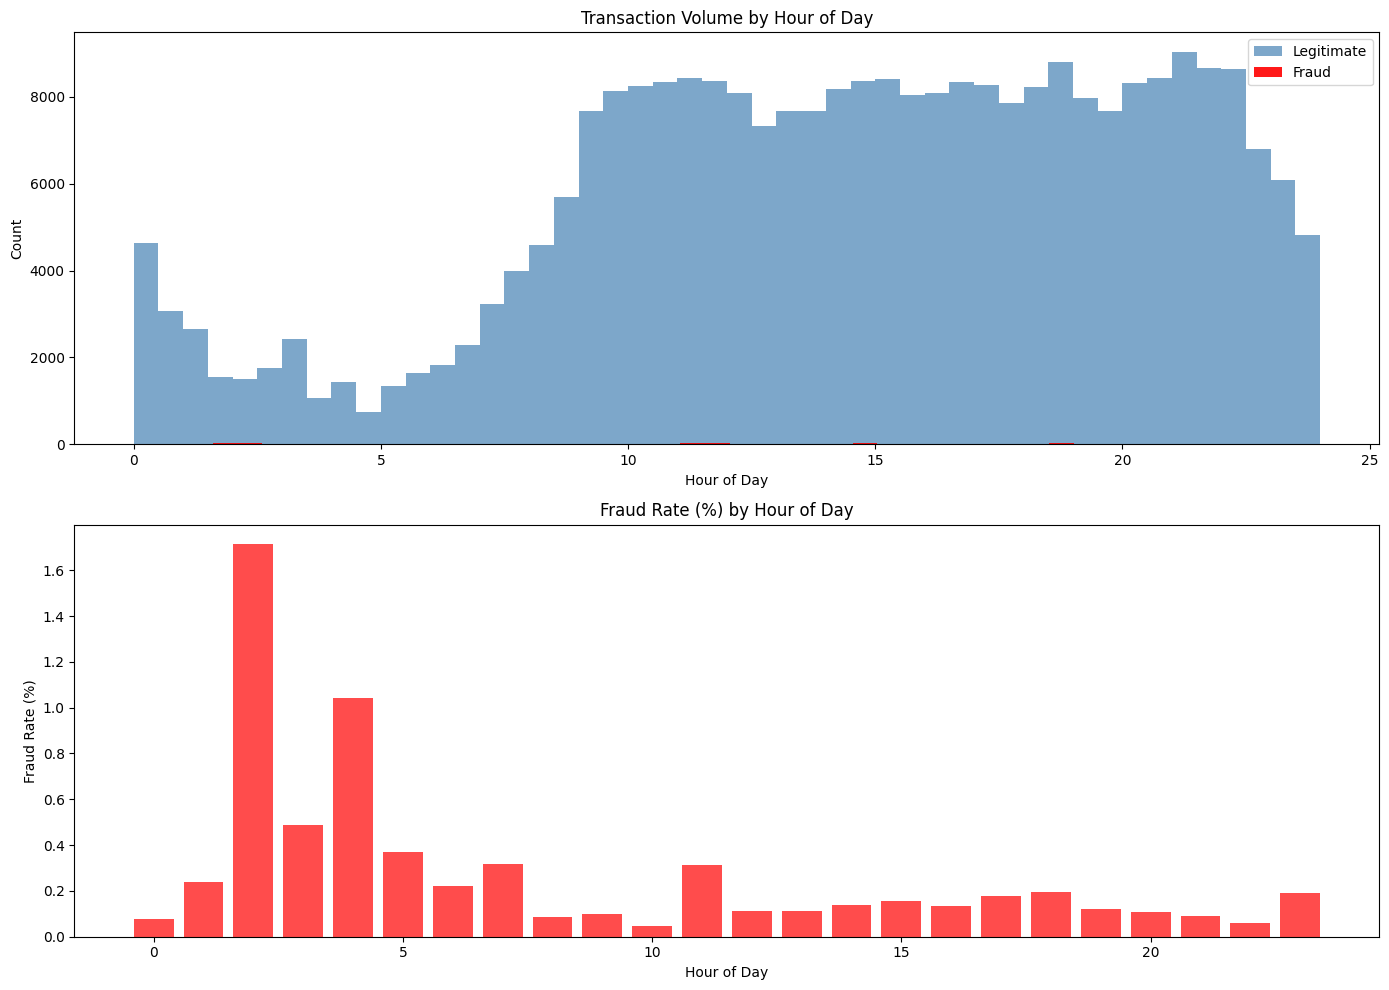


✅ Plot saved to docs/time_analysis.png


In [7]:
# Cell 6: Time Analysis
print("=" * 50)
print("TIME ANALYSIS")
print("=" * 50)

# Convert time to hours
df['Hour'] = (df['Time'] / 3600) % 24
df['Hour_int'] = df['Hour'].astype(int)

fraud_hours = df[df['Class'] == 1]['Hour']
legit_hours = df[df['Class'] == 0]['Hour']

print(f"Dataset covers: {df['Time'].max()/3600:.1f} hours (~2 days)")

# Hourly breakdown table
hourly = df.groupby('Hour_int')['Class'].agg(['sum', 'count'])
hourly.columns = ['Fraud_Count', 'Total_Count']
hourly['Legit_Count'] = hourly['Total_Count'] - hourly['Fraud_Count']
hourly['Fraud_Rate_%'] = (hourly['Fraud_Count'] / hourly['Total_Count'] * 100).round(4)

print("\n" + "=" * 60)
print("HOURLY BREAKDOWN: Legitimate vs Fraud")
print("=" * 60)
print(f"{'Hour':<6} {'Total':>8} {'Legit':>8} {'Fraud':>8} {'Fraud%':>10}")
print("-" * 60)
for hour, row in hourly.iterrows():
    print(f"{hour:<6} {int(row['Total_Count']):>8,} {int(row['Legit_Count']):>8,} "
          f"{int(row['Fraud_Count']):>8} {row['Fraud_Rate_%']:>10.4f}%")

print("-" * 60)
print(f"{'TOTAL':<6} {len(df):>8,} {len(df[df['Class']==0]):>8,} "
      f"{len(df[df['Class']==1]):>8} {len(df[df['Class']==1])/len(df)*100:>10.4f}%")

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Transaction volume over time
axes[0].hist(legit_hours, bins=48, color='steelblue',
             alpha=0.7, label='Legitimate')
axes[0].hist(fraud_hours, bins=48, color='red',
             alpha=0.9, label='Fraud')
axes[0].set_title('Transaction Volume by Hour of Day')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Count')
axes[0].legend()

# Plot 2: Fraud rate by hour
axes[1].bar(hourly.index, hourly['Fraud_Rate_%'], color='red', alpha=0.7)
axes[1].set_title('Fraud Rate (%) by Hour of Day')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.savefig('../../docs/time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Plot saved to docs/time_analysis.png")

In [8]:
# Cell 7: Missing Values & Duplicates Check
print("=" * 50)
print("DATA QUALITY CHECK")
print("=" * 50)

# Missing values
missing = df.isnull().sum()
print(f"\nMissing Values:")
print(f"Total missing: {missing.sum()}")
if missing.sum() == 0:
    print("✅ No missing values found!")
else:
    print(missing[missing > 0])

# Duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows:")
print(f"Total duplicates: {duplicates}")
if duplicates == 0:
    print("✅ No duplicate rows found!")
else:
    print(f"⚠️ Found {duplicates} duplicate rows!")

# Negative values check
print("\nNegative Values Check:")
neg_amount = (df['Amount'] < 0).sum()
neg_time = (df['Time'] < 0).sum()
print(f"Negative Amount values: {neg_amount}")
print(f"Negative Time values: {neg_time}")
if neg_amount == 0 and neg_time == 0:
    print("✅ No negative values in Amount or Time!")

# Zero amount transactions
zero_amount = (df['Amount'] == 0).sum()
print(f"\nZero Amount Transactions: {zero_amount}")
print(f"Zero Amount in Fraud: {(fraud['Amount'] == 0).sum()}")
print(f"Zero Amount in Legit: {(legitimate['Amount'] == 0).sum()}")

print("\n" + "=" * 50)
print("DATA QUALITY SUMMARY")
print("=" * 50)
print(f"✅ Total Records:     {len(df):,}")
print(f"✅ Missing Values:    {missing.sum()}")
print(f"✅ Duplicates:        {duplicates}")
print(f"✅ Negative Amounts:  {neg_amount}")
print(f"✅ Data is clean and ready for modeling!")

DATA QUALITY CHECK

Missing Values:
Total missing: 0
✅ No missing values found!

Duplicate Rows:
Total duplicates: 1081
⚠️ Found 1081 duplicate rows!

Negative Values Check:
Negative Amount values: 0
Negative Time values: 0
✅ No negative values in Amount or Time!

Zero Amount Transactions: 1825
Zero Amount in Fraud: 27
Zero Amount in Legit: 1798

DATA QUALITY SUMMARY
✅ Total Records:     284,807
✅ Missing Values:    0
✅ Duplicates:        1081
✅ Negative Amounts:  0
✅ Data is clean and ready for modeling!


In [9]:
# Cell 8: Handle Duplicates
print("=" * 50)
print("DUPLICATE ANALYSIS")
print("=" * 50)

# Check duplicates in fraud vs legitimate
dup_mask = df.duplicated(keep=False)
duplicates_df = df[dup_mask]

print(f"Total rows involved in duplication: {len(duplicates_df)}")
print(f"Duplicates in Fraud class:     {duplicates_df[duplicates_df['Class']==1].shape[0]}")
print(f"Duplicates in Legit class:     {duplicates_df[duplicates_df['Class']==0].shape[0]}")

# Remove duplicates
df_clean = df.drop_duplicates(keep='first')

print(f"\nBefore removal: {len(df):,} rows")
print(f"After removal:  {len(df_clean):,} rows")
print(f"Removed:        {len(df) - len(df_clean):,} rows")

# Verify class distribution after cleaning
fraud_clean = df_clean[df_clean['Class'] == 1]
legit_clean = df_clean[df_clean['Class'] == 0]

print("\n" + "=" * 50)
print("CLASS DISTRIBUTION AFTER CLEANING")
print("=" * 50)
print(f"Total:      {len(df_clean):,}")
print(f"Legitimate: {len(legit_clean):,} ({len(legit_clean)/len(df_clean)*100:.4f}%)")
print(f"Fraud:      {len(fraud_clean):,} ({len(fraud_clean)/len(df_clean)*100:.4f}%)")

print("\n✅ Duplicates removed successfully!")
print("✅ df_clean is our working dataset going forward!")

DUPLICATE ANALYSIS
Total rows involved in duplication: 1854
Duplicates in Fraud class:     32
Duplicates in Legit class:     1822

Before removal: 284,807 rows
After removal:  283,726 rows
Removed:        1,081 rows

CLASS DISTRIBUTION AFTER CLEANING
Total:      283,726
Legitimate: 283,253 (99.8333%)
Fraud:      473 (0.1667%)

✅ Duplicates removed successfully!
✅ df_clean is our working dataset going forward!


CORRELATION ANALYSIS

TOP 10 NEGATIVE CORRELATIONS WITH FRAUD:
V17   -0.3135
V14   -0.2934
V12   -0.2507
V10   -0.2070
V16   -0.1872
V3    -0.1823
V7    -0.1723
V18   -0.1053
V1    -0.0945
V9    -0.0940

TOP 10 POSITIVE CORRELATIONS WITH FRAUD:
Amount   0.0058
V28      0.0097
V20      0.0215
V27      0.0219
V21      0.0264
V8       0.0331
V19      0.0336
V2       0.0846
V4       0.1293
V11      0.1491


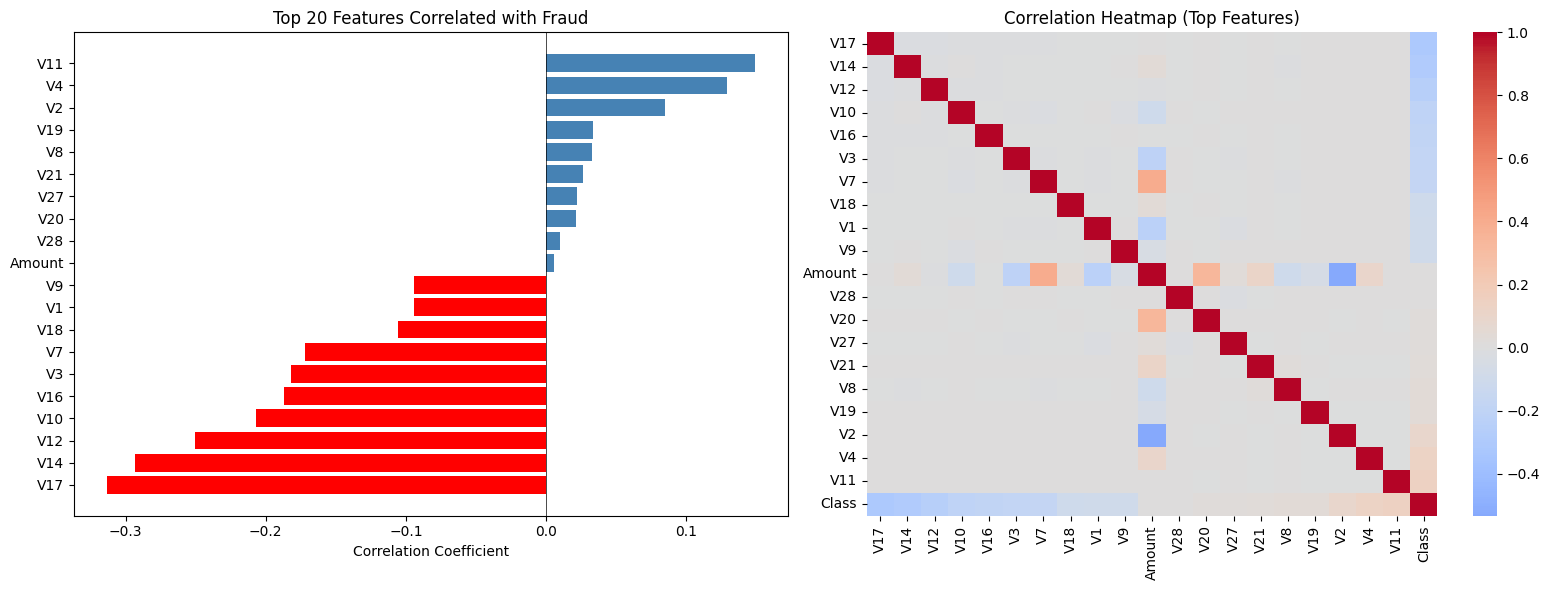


✅ Plot saved to docs/correlation_analysis.png


In [10]:
# Cell 9: Feature Correlation Analysis
print("=" * 50)
print("CORRELATION ANALYSIS")
print("=" * 50)

# Correlation of all features with Class
correlations = df_clean.corr()['Class'].drop('Class').sort_values()

print("\nTOP 10 NEGATIVE CORRELATIONS WITH FRAUD:")
print(correlations.head(10).to_string())

print("\nTOP 10 POSITIVE CORRELATIONS WITH FRAUD:")
print(correlations.tail(10).to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Top correlated features
top_features = pd.concat([correlations.head(10), correlations.tail(10)])
colors = ['red' if x < 0 else 'steelblue' for x in top_features.values]
axes[0].barh(top_features.index, top_features.values, color=colors)
axes[0].set_title('Top 20 Features Correlated with Fraud')
axes[0].set_xlabel('Correlation Coefficient')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Plot 2: Heatmap of top features only
top_feature_names = top_features.index.tolist() + ['Class']
corr_matrix = df_clean[top_feature_names].corr()
sns.heatmap(corr_matrix, 
            annot=False, 
            cmap='coolwarm', 
            center=0,
            ax=axes[1])
axes[1].set_title('Correlation Heatmap (Top Features)')

plt.tight_layout()
plt.savefig('../../docs/correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Plot saved to docs/correlation_analysis.png")

In [11]:
# Cell 10: EDA Summary
print("=" * 60)
print("EDA COMPLETE - KEY FINDINGS SUMMARY")
print("=" * 60)

print("""
📊 DATASET:
   • Total transactions:  283,726 (after cleaning)
   • Features:            30 (V1-V28, Time, Amount)
   • Target:              Class (0=Legitimate, 1=Fraud)

⚖️ CLASS IMBALANCE:
   • Legitimate:          283,253 (99.83%)
   • Fraud:               473 (0.17%)
   • Imbalance ratio:     ~599:1
   • ⚠️ Accuracy is MISLEADING - must use Precision/Recall/F1

🧹 DATA QUALITY:
   • Missing values:      0 ✅
   • Duplicates removed:  1,081 ✅
   • Negative amounts:    0 ✅

💰 AMOUNT INSIGHTS:
   • Avg legitimate:      $88.29
   • Avg fraud:           $122.21
   • Fraud median:        $9.25 (many small fraud transactions)

🕐 TIME INSIGHTS:
   • Hour 2 (2AM):        Highest fraud rate (1.71%)
   • Hour 4 (4AM):        Second highest (1.04%)
   • Daytime hours:       Low fraud rates

🔑 TOP FRAUD INDICATORS:
   • Negative: V17, V14, V12, V10, V16
   • Positive: V11, V4, V2
   • Amount:   Almost no correlation (0.006)
""")

# Save clean dataset
df_clean.to_csv('../../data/processed/creditcard_clean.csv', index=False)
print("✅ Clean dataset saved to data/processed/creditcard_clean.csv")
print("\n🎉 EDA NOTEBOOK COMPLETE - Ready for Phase 3: Preprocessing!")

EDA COMPLETE - KEY FINDINGS SUMMARY

📊 DATASET:
   • Total transactions:  283,726 (after cleaning)
   • Features:            30 (V1-V28, Time, Amount)
   • Target:              Class (0=Legitimate, 1=Fraud)

⚖️ CLASS IMBALANCE:
   • Legitimate:          283,253 (99.83%)
   • Fraud:               473 (0.17%)
   • Imbalance ratio:     ~599:1
   • ⚠️ Accuracy is MISLEADING - must use Precision/Recall/F1

🧹 DATA QUALITY:
   • Missing values:      0 ✅
   • Duplicates removed:  1,081 ✅
   • Negative amounts:    0 ✅

💰 AMOUNT INSIGHTS:
   • Avg legitimate:      $88.29
   • Avg fraud:           $122.21
   • Fraud median:        $9.25 (many small fraud transactions)

🕐 TIME INSIGHTS:
   • Hour 2 (2AM):        Highest fraud rate (1.71%)
   • Hour 4 (4AM):        Second highest (1.04%)
   • Daytime hours:       Low fraud rates

🔑 TOP FRAUD INDICATORS:
   • Negative: V17, V14, V12, V10, V16
   • Positive: V11, V4, V2
   • Amount:   Almost no correlation (0.006)

✅ Clean dataset saved to data/proce